# Practical 1: Boston Housing Price Prediction using DNN Regression

## Aim
Implement the Boston housing price prediction problem using a Deep Neural Network for regression.

## Dataset
Local file used in this notebook: dl/1/HousingData.csv

## What you will learn
- How to load a regression dataset
- How to handle missing values
- How to split data into train and test sets
- Why feature scaling is important for neural networks
- How to build a simple DNN model with one numeric output
- How to evaluate regression using MAE, MSE, and RMSE

Note: This notebook uses TensorFlow/Keras. No PyTorch code is used.

In [1]:
# If imports fail on your machine, install these packages once:
%pip install pandas numpy scikit-learn matplotlib tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Step 1: Load the dataset

The target column is MEDV. It stores the median value of owner-occupied homes in thousands of dollars.
All other columns are input features.

In [4]:
DATA_PATH = Path("dl/1/HousingData.csv")

data = pd.read_csv(DATA_PATH)
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [5]:
# Check the column names and missing values.
print(data.info())
print("\nMissing values per column:")
print(data.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None

Missing values per column:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


## Step 2: Clean the data

Neural networks cannot train with missing values. For a simple practical, we replace missing numeric values with the mean of that column.

In [6]:
data = data.fillna(data.mean(numeric_only=True))

X = data.drop("MEDV", axis=1)
y = data["MEDV"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (506, 13)
Target shape: (506,)


## Step 3: Split and scale

Feature scaling keeps all input columns in a similar numeric range. This helps the DNN learn faster and more stable weights.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 404
Testing samples: 102


## Step 4: Build the DNN regression model

For regression, the final layer has one neuron and no activation function. This lets the model predict any numeric price.

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Train the model

EarlyStopping stops training when validation loss stops improving. This prevents unnecessary training and helps reduce overfitting.

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 601.6872 - mae: 22.6183 - rmse: 24.5293 - val_loss: 514.8871 - val_mae: 21.1463 - val_rmse: 22.6911
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 537.4208 - mae: 21.2541 - rmse: 23.1823 - val_loss: 451.9494 - val_mae: 19.6961 - val_rmse: 21.2591
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 453.5311 - mae: 19.3658 - rmse: 21.2963 - val_loss: 360.6490 - val_mae: 17.4050 - val_rmse: 18.9908
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 337.2636 - mae: 16.3393 - rmse: 18.3647 - val_loss: 244.7369 - val_mae: 13.8717 - val_rmse: 15.6441
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 212.8797 - mae: 12.2881 - rmse: 14.5904 - val_loss: 140.0716 - val_mae: 9.5898 - val_rmse: 11.8352
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 123.9985 - mae: 8.8907 - rmse: 11.1355 - val_loss: 77.6594 - val_mae: 6.5690 - val_rmse: 8.8125
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

## Step 6: Visualize training

If validation loss becomes much higher than training loss, the model may be overfitting.

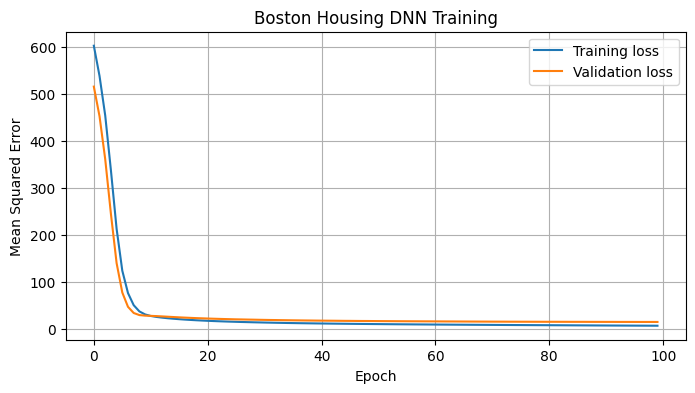

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Boston Housing DNN Training")
plt.legend()
plt.grid(True)
plt.show()

## Step 7: Evaluate the model

Lower MAE and RMSE are better. R2 closer to 1 is better.

In [12]:
y_pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2   : {r2:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
MAE  : 2.403
MSE  : 14.216
RMSE : 3.770
R2   : 0.806


In [13]:
comparison = pd.DataFrame({
    "Actual MEDV": y_test.values[:10],
    "Predicted MEDV": y_pred[:10]
})

comparison

,Actual MEDV,Predicted MEDV
0,23.6,28.309851
1,32.4,36.546597
2,13.6,16.433941
3,22.8,26.508488
4,16.1,14.172687
5,20.0,19.992046
6,17.8,16.558643
7,14.0,15.709408
8,19.6,22.710354
9,16.8,18.443588


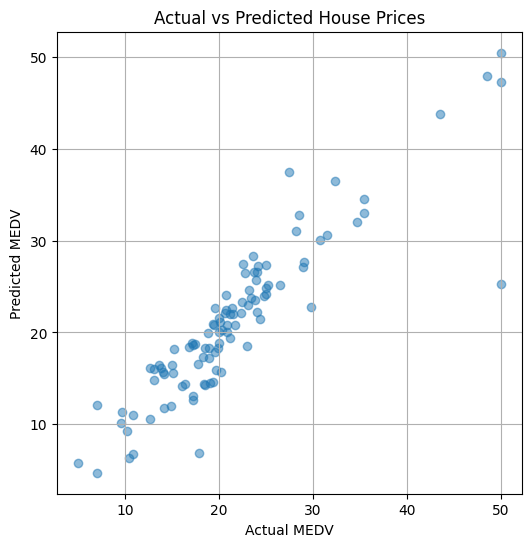

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

## Conclusion

We created a DNN regression model for Boston housing price prediction. The important steps were data cleaning, feature scaling, model training, and evaluation using regression metrics.